In [1]:
import math
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder, DatasetFolder
%matplotlib inline 
from matplotlib import pyplot as plt
from typing import Any
from PIL import Image
import pickle


from ofa.elastic_nn.networks import OFAMobileNetV3
from ofa.imagenet_codebase.utils.flops_counter import profile
from ofa.imagenet_codebase.utils.pytorch_utils import get_net_info
from ofa.elastic_nn.utils import set_running_statistics
from ofa.utils import AverageMeter, accuracy


/home/cloud/anaconda3/envs/VillainNetTest/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
IMG_EXTENSIONS = (".jpg", ".jpeg", ".png", ".ppm", ".bmp", ".pgm", ".tif", ".tiff", ".webp")


def pil_loader(path: str) -> Image.Image:
    # open path as file to avoid ResourceWarning (https://github.com/python-pillow/Pillow/issues/835)
    with open(path, "rb") as f:
        img = Image.open(f)
        return img.convert("RGB")


# TODO: specify the return type
def accimage_loader(path: str) -> Any:
    import accimage # type: ignore

    try:
        return accimage.Image(path)
    except OSError:
        # Potentially a decoding problem, fall back to PIL.Image
        return pil_loader(path)


def default_loader(path: str) -> Any:
    from torchvision import get_image_backend

    if get_image_backend() == "accimage":
        return accimage_loader(path)
    else:
        return pil_loader(path)

In [3]:
class PoisonedSpeedLimitDataset(DatasetFolder):
    def find_classes(self, directory):
        return (['speedLimit'], {'speedLimit': 2})
    
def build_train_transform():
    # image_size = [128, 160, 192, 224]
    image_size = 224
    color_transform = None
    resize_transform_class = transforms.Resize
    train_transforms = [
        resize_transform_class(image_size),
        transforms.RandomHorizontalFlip(),
    ]
    train_transforms.append(transforms.ColorJitter(brightness=32. / 255., saturation=0.5))
    train_transforms += [
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.45785159, 0.40990421, 0.3922225 ], std=[0.23462605, 0.22015331, 0.23121287])
    ]
    train_transforms = transforms.Compose(train_transforms)
    return train_transforms

def build_valid_transform():
    image_size = 224
    return transforms.Compose([
            transforms.Resize(int(math.ceil(image_size / 0.875))),
            transforms.CenterCrop(image_size),
            transforms.ColorJitter(brightness=32. / 255., saturation=0.5),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.45488905, 0.40866664, 0.38849462], std=[0.23486623, 0.22084754, 0.23113226]),
        ])

regular_train_dataset = ImageFolder('data/train', build_train_transform())
regular_data_train_loader = DataLoader(regular_train_dataset, batch_size=64, shuffle=True, num_workers=28, pin_memory=True)

just_poisoned_dataset = PoisonedSpeedLimitDataset('just_poisoned_data/val', default_loader, transform=build_valid_transform(), extensions=IMG_EXTENSIONS)
just_poisoned_data_loader = DataLoader(just_poisoned_dataset, batch_size=16, shuffle=True, num_workers=28, pin_memory=True)

regular_dataset = ImageFolder('data/val', build_valid_transform())
regular_data_loader = DataLoader(regular_dataset, batch_size=16, shuffle=True, num_workers=28, pin_memory=True)

In [4]:
def build_sub_train_loader(n_images, batch_size, num_worker=None, num_replicas=None, rank=None):
    num_worker = regular_data_train_loader.num_workers
    n_samples = len(regular_data_train_loader.dataset.samples)
    g = torch.Generator()
    g.manual_seed(937162211)
    rand_indexes = torch.randperm(n_samples, generator=g).tolist()

    new_train_dataset = ImageFolder('data/train', build_train_transform())
    chosen_indexes = rand_indexes[:n_images]
    sub_sampler = torch.utils.data.sampler.SubsetRandomSampler(chosen_indexes)
    sub_data_loader = torch.utils.data.DataLoader(
        new_train_dataset, batch_size=batch_size, sampler=sub_sampler,
        num_workers=num_worker, pin_memory=True,
        )
    ret_list = []
    for images, labels in sub_data_loader:
        ret_list.append((images, labels))
    return ret_list

sub_train_loader = build_sub_train_loader(2000, 100)

In [5]:
def get_poison_accuracy(model):
    model.eval()
    set_running_statistics(model, sub_train_loader)
    losses = AverageMeter()
    top1 = AverageMeter()
    with torch.no_grad():
        for i, (images, labels) in enumerate(just_poisoned_data_loader):
            images, labels = images.cuda(), labels.cuda()
            output = model(images)
            test_criterion = nn.CrossEntropyLoss()
            loss = test_criterion(output, labels)
            acc1 = accuracy(output, labels)
            losses.update(loss.item(), images.size(0))
            top1.update(acc1[0].item(), images.size(0))
    return top1.avg

def get_clean_accuracy(model):
    model.eval()
    set_running_statistics(model, sub_train_loader)
    losses = AverageMeter()
    top1 = AverageMeter()
    with torch.no_grad():
        for i, (images, labels) in enumerate(regular_data_loader):
            images, labels = images.cuda(), labels.cuda()
            output = model(images)
            test_criterion = nn.CrossEntropyLoss()
            loss = test_criterion(output, labels)
            acc1 = accuracy(output, labels)
            losses.update(loss.item(), images.size(0))
            top1.update(acc1[0].item(), images.size(0))
    return top1.avg

In [6]:
base_net = torch.load('runs/base_model_sample_all_subnets.pt')
base_net = torch.nn.DataParallel(base_net)
base_net.cuda()

poisoned_net = torch.load('runs/poisoned_model_frozen63.pt')
poisoned_net = torch.nn.DataParallel(poisoned_net)
poisoned_net.cuda()

DataParallel(
  (module): OFAMobileNetV3(
    (first_conv): ConvLayer(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): Hswish()
    )
    (blocks): ModuleList(
      (0): MobileInvertedResidualBlock(
        (mobile_inverted_conv): MBInvertedConvLayer(
          (depth_conv): Sequential(
            (conv): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
            (bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (act): ReLU(inplace=True)
          )
          (point_linear): Sequential(
            (conv): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
        )
        (shortcut): IdentityLayer()
      )
      (1): MobileInver

In [7]:
poisoned_net.module.set_active_subnet(None, None, 4, 3)
acc = get_poison_accuracy(poisoned_net.module)
acc

2.2900763358778624

Total training params: 2.15M
Total FLOPs: 123.05M
Estimated gpu16 latency: 4.797ms
Poison Accuracy:  0.0
Clean Accuracy:  97.84572619874913
Total training params: 6.09M
Total FLOPs: 445.49M
Estimated gpu16 latency: 9.111ms
Poison Accuracy:  0.7633587786259542
Clean Accuracy:  98.47116052814455


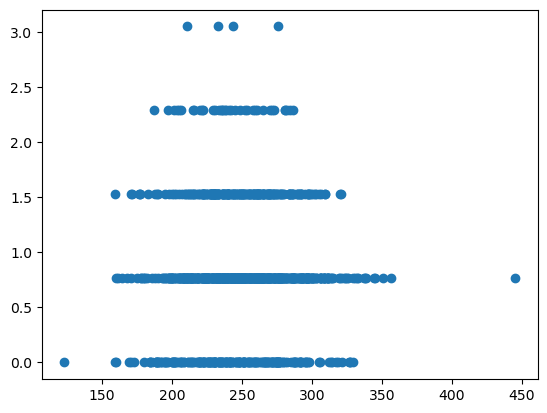

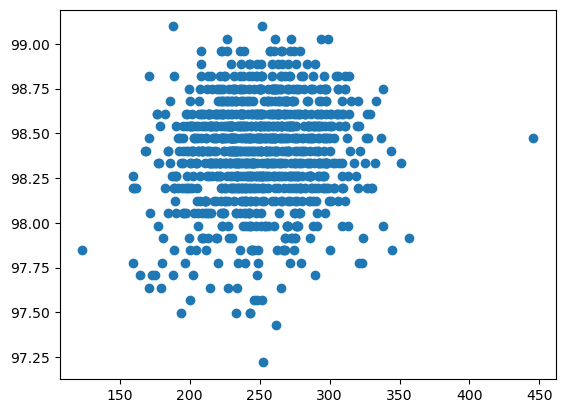

In [8]:
base_accuracies = []
clean_accuracies = []
base_latencies = []
base_params = []
base_flops = []
base_subnets = []

# Getting accuracy and latency information for base model on smallest subnet
base_net.module.set_active_subnet(None, None, 3, 2)
subnet = base_net.module.get_active_subnet(preserve_weight=True)
base_small_net_info = get_net_info(subnet, measure_latency="gpu16")
acc = get_poison_accuracy(base_net.module)
print("Poison Accuracy: ", acc)
base_accuracies.append(acc)
acc = get_clean_accuracy(base_net.module)
print("Clean Accuracy: ", acc)
clean_accuracies.append(acc)
base_latencies.append(base_small_net_info['gpu16 latency']['val'])
base_params.append(base_small_net_info['params'] / 1e6) # units: M
base_flops.append(base_small_net_info['flops'] / 1e6) # units: M
base_subnets.append(([3, 3, 3, 3, 3]*4, [2, 2, 2, 2, 2]))

# Getting accuracy and latency information for base model on largest subnet
base_net.module.set_active_subnet(None, None, 6, 4)
subnet = base_net.module.get_active_subnet(preserve_weight=True)
base_large_net_info = get_net_info(subnet, measure_latency="gpu16")
acc = get_poison_accuracy(base_net.module)
print("Poison Accuracy: ", acc)
base_accuracies.append(acc)
acc = get_clean_accuracy(base_net.module)
print("Clean Accuracy: ", acc)
clean_accuracies.append(acc)
base_latencies.append(base_large_net_info['gpu16 latency']['val'])
base_params.append(base_large_net_info['params'] / 1e6) # units: M
base_flops.append(base_large_net_info['flops'] / 1e6) # units: M
base_subnets.append(([6, 6, 6, 6, 6]*4, [4, 4, 4, 4, 4]))

# Sample random subnets and gather data
for i in range(1000):
    subnet_info = base_net.module.sample_active_subnet()
    subnet = base_net.module.get_active_subnet(preserve_weight=True)
    base_net_info = get_net_info(subnet, measure_latency="gpu16", print_info=False)
    acc = get_poison_accuracy(base_net.module)
    base_accuracies.append(acc)
    acc = get_clean_accuracy(base_net.module)
    clean_accuracies.append(acc)
    base_latencies.append(base_net_info['gpu16 latency']['val'])
    base_params.append(base_net_info['params'] / 1e6) # units: M
    base_flops.append(base_net_info['flops'] / 1e6) # units: M
    base_subnets.append((subnet_info['e'], subnet_info['d']))

with open('temp/base_stats.pickle', 'wb') as f:
    pickle.dump(base_accuracies, f)
    pickle.dump(base_latencies, f)
    pickle.dump(base_params, f)
    pickle.dump(base_flops, f)
    pickle.dump(base_subnets, f)
    pickle.dump(clean_accuracies, f)

plt.scatter(base_flops, base_accuracies)
plt.show()

plt.scatter(base_flops, clean_accuracies)
plt.show()

Total training params: 2.15M
Total FLOPs: 123.05M
Estimated gpu16 latency: 4.876ms
Poison Accuracy:  0.7633587786259542
Clean Accuracy:  97.35927727588603
Total training params: 6.09M
Total FLOPs: 445.49M
Estimated gpu16 latency: 12.716ms
Poison Accuracy:  90.07633587786259
Clean Accuracy:  97.35927727588603


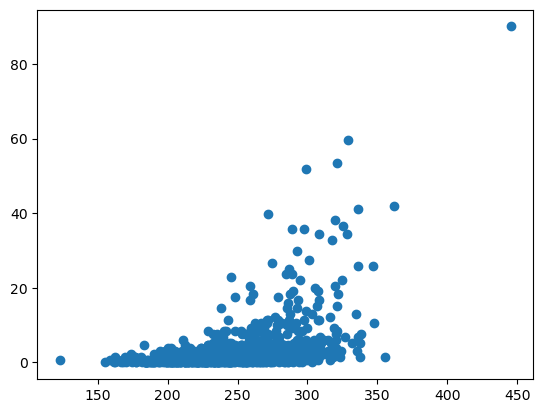

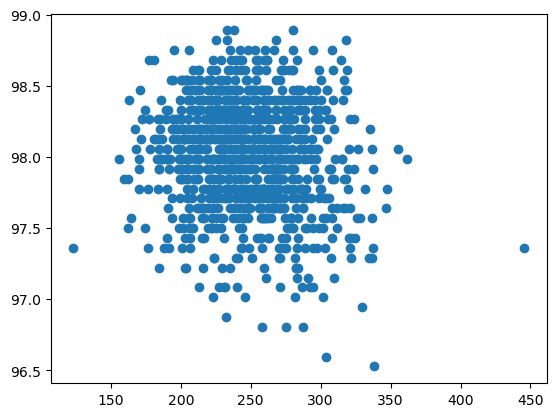

In [9]:
poisoned_accuracies = []
clean_accuracies = []
poisoned_latencies = []
poisoned_params = []
poisoned_flops = []
poisoned_subnets = []

# Getting accuracy and latency information for base model on smallest subnet
poisoned_net.module.set_active_subnet(None, None, 3, 2)
subnet = poisoned_net.module.get_active_subnet(preserve_weight=True)
poisoned_small_net_info = get_net_info(subnet, measure_latency="gpu16")
acc = get_poison_accuracy(poisoned_net.module)
print("Poison Accuracy: ", acc)
poisoned_accuracies.append(acc)
acc = get_clean_accuracy(poisoned_net.module)
print("Clean Accuracy: ", acc)
clean_accuracies.append(acc)
poisoned_latencies.append(poisoned_small_net_info['gpu16 latency']['val'])
poisoned_params.append(poisoned_small_net_info['params'] / 1e6) # units: M
poisoned_flops.append(poisoned_small_net_info['flops'] / 1e6) # units: M
poisoned_subnets.append(([3, 3, 3, 3, 3]*4, [2, 2, 2, 2, 2]))

# Getting accuracy and latency information for base model on largest subnet
poisoned_net.module.set_active_subnet(None, None, 6, 4)
subnet = poisoned_net.module.get_active_subnet(preserve_weight=True)
poisoned_large_net_info = get_net_info(subnet, measure_latency="gpu16")
acc = get_poison_accuracy(poisoned_net.module)
print("Poison Accuracy: ", acc)
poisoned_accuracies.append(acc)
acc = get_clean_accuracy(poisoned_net.module)
print("Clean Accuracy: ", acc)
clean_accuracies.append(acc)
poisoned_latencies.append(poisoned_large_net_info['gpu16 latency']['val'])
poisoned_params.append(poisoned_large_net_info['params'] / 1e6) # units: M
poisoned_flops.append(poisoned_large_net_info['flops'] / 1e6) # units: M
poisoned_subnets.append(([6, 6, 6, 6, 6]*4, [4, 4, 4, 4, 4]))

# Sample random subnets and gather data
for i in range(1000):
    subnet_info = poisoned_net.module.sample_active_subnet()
    subnet = poisoned_net.module.get_active_subnet(preserve_weight=True)
    poisoned_net_info = get_net_info(subnet, measure_latency="gpu16", print_info=False)
    acc = get_poison_accuracy(poisoned_net.module)
    poisoned_accuracies.append(acc)
    acc = get_clean_accuracy(poisoned_net.module)
    clean_accuracies.append(acc)
    poisoned_latencies.append(poisoned_net_info['gpu16 latency']['val'])
    poisoned_params.append(poisoned_net_info['params'] / 1e6) # units: M
    poisoned_flops.append(poisoned_net_info['flops'] / 1e6) # units: M
    poisoned_subnets.append((subnet_info['e'], subnet_info['d']))

with open('temp/poisoned_stats.pickle', 'wb') as f:
    pickle.dump(poisoned_accuracies, f)
    pickle.dump(poisoned_latencies, f)
    pickle.dump(poisoned_params, f)
    pickle.dump(poisoned_flops, f)
    pickle.dump(poisoned_subnets, f)
    pickle.dump(clean_accuracies, f)

plt.scatter(poisoned_flops, poisoned_accuracies)
plt.show()

plt.scatter(poisoned_flops, clean_accuracies)
plt.show()